In [1]:
from ESN import Reservoir
from narma import NARMA
from Qreservoir_fast import QReservoir
from tools import gen_input_states, gen_system_filepath, gen_result_filepath, write_to_row, finish_row

from json import load
import numpy as np
import matplotlib.pyplot as plt
import os

#Pyörittelyt --------------------------------------------------------

In [2]:
classic = Reservoir(128)
classic.add_performance_task(NARMA(degree_=6))
classic.generate_inputs([1000,3000,5000])
classic.evolve_reservoir('task1', 'full')
classic.results['task1']

Added performance task 'NARMA(6, 0.3, 0.05, 0.375, 0)' as 'task1'


('NARMA(6, 0.3, 0.05, 0.375, 0)', np.float64(0.01258035121895656))

In [ ]:
for i in range(50):
    jeps = Reservoir(128, 0.9, 0.1)
    jeps.add_performance_task(NARMA(degree_=6))
    jeps.generate_inputs([1000,5000,3000])
    jeps.evolve_reservoir('task1', 'full')
    print(jeps.results['task1'])

In [2]:
with open("config.json") as file:
    parameters = load(file)

gamma = parameters["GAMMA"]                                 
reservoir_size = parameters["SIZE"]    
fock_truncation = parameters["TRUNC"]
sim_rounding = parameters["ROUND"]
n_models = parameters["MODELS"]
n_train_inputs = parameters["TRAIN"]
n_test_inputs = parameters["TEST"]

In [3]:
QReservoir_models = [QReservoir(gamma, reservoir_size, fock_truncation, "alltoall", sim_rounding) for _ in range(n_models)]
train_inputs = np.array([gen_input_states("sq_th", n_train_inputs, fock_truncation, sim_rounding) for _ in range(n_models)])

for Qreservoir in QReservoir_models:
    Qreservoir.init_reservoir("vacuum")
    Qreservoir.rk4_timesteps(4)

In [4]:
test_inputs_sq_th = np.array([gen_input_states("sq_th", n_test_inputs, fock_truncation, sim_rounding) for _ in range(n_models)])
test_inputs_sq_pho_add = np.array([gen_input_states("pho_add", n_test_inputs, fock_truncation, sim_rounding) for _ in range(n_models)])
test_inputs_sq_pho_sub = np.array([gen_input_states("pho_sub", n_test_inputs, fock_truncation, sim_rounding) for _ in range(n_models)])
test_inputs_simple = np.array([gen_input_states("simple", n_test_inputs, fock_truncation, sim_rounding) for _ in range(n_models)])

In [ ]:
for i in range(n_models):
    QReservoir_models[i].train_reservoir(train_inputs[i])

In [ ]:
for i in range(n_models):
    QReservoir_models[i].test_reservoir(test_inputs_sq_th[i])

In [ ]:
for i in range(n_models):
    QReservoir_models[i].test_reservoir(test_inputs_sq_pho_add[i])

In [ ]:
for i in range(n_models):
    QReservoir_models[i].test_reservoir(test_inputs_sq_pho_sub[i])

In [ ]:
for i in range(n_models):
    QReservoir_models[i].test_reservoir(test_inputs_simple[i])

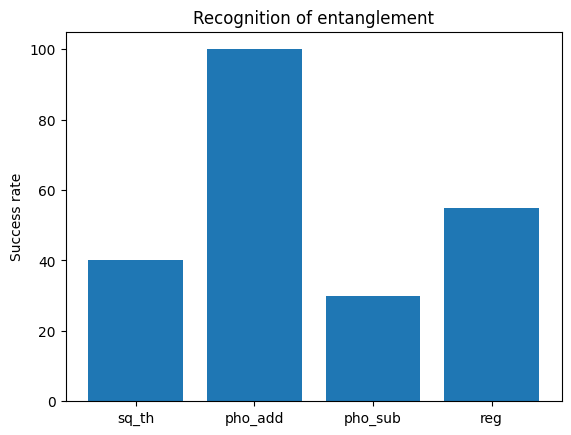

In [ ]:
#Plot the probability of correct classification
fig, ax = plt.subplots()

input_types = ['sq_th', 'pho_add', 'pho_sub', 'reg']
counts = [40, 100, 30, 55]
ax.bar(input_types, counts)

ax.set_ylabel('Success rate')
ax.set_title('Recognition of entanglement')

plt.show()

In [4]:
train_in = gen_input_states("sq_th", 20, fock_truncation, sim_rounding)

test_pho_add = gen_input_states("pho_add", 20, fock_truncation)
test_pho_sub = gen_input_states("pho_sub", 20, fock_truncation)
test_simple = gen_input_states("simple", 20, fock_truncation)

In [19]:
from tools import init_destroy, init_identity, tensor, dagger, init_two_mode_sq, init_vac


In [17]:
truncate = 5
amount_of_states = 30

a1 = tensor([init_destroy(truncate), init_identity(truncate)])
a2 = tensor([init_identity(truncate), init_destroy(truncate)])
        
abs_alpha_pho_add_ = np.random.uniform(0.1, 0.25, (amount_of_states,))
theta_pho_add_ = np.random.uniform(0,2*np.pi,(amount_of_states,))
alpha_pho_add_ = np.array([x*np.exp(1j*y) for x, y in zip(abs_alpha_pho_add_,theta_pho_add_)])  

abs_alpha_pho_sub_ = np.random.uniform(0.8, 0.95, (amount_of_states,))
theta_pho_sub_ = np.random.uniform(0,2*np.pi,(amount_of_states,))
alpha_pho_sub_ = np.array([x*np.exp(1j*y) for x, y in zip(abs_alpha_pho_sub_,theta_pho_sub_)])

theta_simple_ = np.array([np.arcsin(np.sqrt(x)) for x in np.random.uniform(0,1,(amount_of_states,))])
phi_simple_ = np.random.uniform(0,2*np.pi,(amount_of_states,))
c0_simple_ = np.array([np.sin(x) for x in theta_simple_])
c1_simple_ = np.array([np.cos(x)*np.exp(1j*y) for x,y in zip(theta_simple_, phi_simple_)])